<a href="https://colab.research.google.com/github/jeffer301/INTELIGENCIA-ARTIFICIAL--JEFFERSON-VALENCIA/blob/main/Proyecto%20Final%20Inteligencia%20Artificial/notebook/proyecto_final_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificación de la Categoría de Producto en un E-commerce de Repostería con Árbol de Decisión

**Asignatura:** Inteligencia Artificial
**Programa:** Ingeniería de Sistemas — Semestre 8
**Universidad del Pacífico**
**Actividad:** Investigación, implementación y evaluación de un modelo de Machine Learning
**Modelo seleccionado:** Árbol de Decisión (Decision Tree Classifier — `scikit-learn`)

---

## 1. Descripción del problema

Un e-commerce especializado en repostería registra sus transacciones (precio, cantidad, descuento,
tiempo de navegación, envío, etc.), pero **no siempre queda registrada la categoría del producto
comprado** en algunos sistemas de terceros o integraciones. El objetivo de este trabajo es construir
un modelo de **clasificación multiclase** que, a partir de las características numéricas de una
transacción, prediga a cuál de las 5 categorías de producto pertenece la compra:

- Bebidas
- Galletas y Brownies
- Panadería Artesanal
- Postres Individuales
- Tortas Personalizadas

Se seleccionó el **Árbol de Decisión** porque es un modelo interpretable, fácil de visualizar y muy
usado como punto de partida en problemas de clasificación con variables numéricas, lo que lo hace
ideal para un primer acercamiento práctico al Machine Learning supervisado.


## 2. Objetivo del trabajo

**Objetivo general:** Implementar y evaluar un modelo de Árbol de Decisión en Python (scikit-learn)
capaz de clasificar la categoría de producto de una transacción de e-commerce, siguiendo el flujo
completo de un proyecto de Machine Learning: preparación de datos, entrenamiento, validación,
evaluación y análisis crítico de resultados.

**Objetivos específicos:**

1. Investigar los fundamentos teóricos del Árbol de Decisión: cómo funciona, sus ventajas, sus
   limitaciones y cuándo conviene usarlo frente a otros modelos.
2. Preparar el conjunto de datos (limpieza, exploración, selección de variables) evitando fugas de
   información (*data leakage*) y variables redundantes.
3. Entrenar el modelo dividiendo los datos en **Entrenamiento (70%) / Prueba (15%) / Validación (15%)**.
4. Evaluar el modelo con métricas apropiadas para clasificación (accuracy, precision, recall, F1-score,
   matriz de confusión, curva ROC/AUC).
5. Analizar explícitamente el **sobreajuste (overfitting)** y el **subajuste (underfitting)**, y
   justificar si el volumen y la calidad de los datos son suficientes para que el modelo generalice.


## 3. Fundamentación teórica del modelo: Árbol de Decisión

### 3.1 ¿Qué es un Árbol de Decisión?

Un **Árbol de Decisión** (*Decision Tree*) es un modelo supervisado que aprende una serie de
reglas tipo *"si-entonces"* organizadas en forma de árbol. Cada **nodo interno** pregunta algo sobre
una variable (por ejemplo, *¿Precio_Unitario ≤ 45000?*), cada **rama** representa la respuesta a esa
pregunta, y cada **hoja** representa una predicción final (una clase, en este caso una categoría de
producto).

Documentación oficial utilizada como referencia: [scikit-learn — Decision Trees](https://scikit-learn.org/stable/modules/tree.html)

### 3.2 Fundamento matemático: ¿cómo elige el árbol sus preguntas?

En cada nodo, el algoritmo (CART, el que usa scikit-learn) prueba distintas variables y distintos
puntos de corte, y elige la combinación que **mejor separa las clases**. Para medir qué tan "mezcladas"
están las clases en un nodo se usa una métrica de **impureza**, principalmente:

- **Índice de Gini** (por defecto en scikit-learn):

$$Gini = 1 - \sum_{i=1}^{C} p_i^2$$

- **Entropía** (usada en la *ganancia de información*):

$$Entropía = - \sum_{i=1}^{C} p_i \log_2(p_i)$$

Donde $p_i$ es la proporción de ejemplos de la clase $i$ en ese nodo y $C$ es el número de clases.
Un nodo con **Gini = 0** o **Entropía = 0** es un nodo "puro" (solo hay una clase). El árbol divide el
nodo por la variable y el punto de corte que **más reduce la impureza** entre el nodo padre y los
nodos hijos (esa reducción se llama *ganancia de información*). Este proceso se repite de forma
recursiva hasta cumplir un criterio de parada (profundidad máxima, mínimo de muestras por hoja, etc.).

### 3.3 Ventajas

- Es fácil de interpretar y de visualizar (se puede "leer" como un diagrama de flujo).
- No requiere que los datos estén normalizados o escalados.
- Puede manejar variables numéricas y categóricas.
- Captura relaciones no lineales entre variables.

### 3.4 Limitaciones

- **Tiende a sobreajustarse** (overfitting) si se deja crecer sin límite, ya que puede memorizar
  incluso el ruido de los datos de entrenamiento.
- Es **inestable**: pequeños cambios en los datos pueden producir árboles muy distintos (alta varianza).
- No siempre logra la mejor precisión posible en comparación con modelos de conjunto (ensamble) como
  Random Forest o Gradient Boosting, que combinan muchos árboles.

### 3.5 Comparación con otros modelos

| Modelo | Interpretabilidad | Maneja no linealidad | Riesgo de overfitting | Necesita escalado |
|---|---|---|---|---|
| **Árbol de Decisión** | Muy alta | Sí | Alto (si no se controla la profundidad) | No |
| Regresión Logística | Alta | No (relaciones lineales) | Bajo | Sí |
| K-Nearest Neighbors (KNN) | Media | Sí | Medio (sensible a *k*) | Sí |
| Random Forest | Media-baja | Sí | Bajo (promedia varios árboles) | No |

### 3.6 Justificación de la elección

Se eligió el Árbol de Decisión porque el problema es de **clasificación multiclase con variables
numéricas**, el equipo se encuentra en una etapa introductoria de Machine Learning y el modelo permite
**visualizar exactamente qué reglas está aprendiendo**, lo cual facilita explicar y defender los
resultados, además de que es la base conceptual de modelos más avanzados como Random Forest.


## 4. Descripción del conjunto de datos

El dataset `ecommerce_reposteria_10000.csv` contiene **10.000 transacciones** de una tienda en línea
de repostería, con las siguientes 9 columnas:

| Columna | Tipo | Descripción |
|---|---|---|
| `ID_Transaccion` | Entero | Identificador único de la transacción (no aporta información predictiva) |
| `Categoria_Producto` | Texto (5 clases) | **Variable objetivo (target)** a predecir |
| `Precio_Unitario` | Numérico | Precio por unidad del producto |
| `Cantidad` | Entero | Unidades compradas |
| `Descuento_Aplicado` | Numérico (0–1) | Porcentaje de descuento aplicado |
| `Tiempo_En_Web_Minutos` | Numérico | Minutos que el cliente pasó en el sitio antes de comprar |
| `Distancia_Envio_Km` | Numérico | Distancia de envío en kilómetros |
| `Costo_Envio` | Numérico | Costo del envío |
| `Total_Compra` | Numérico | Valor total de la transacción |

El dataset fue generado de forma sintética/aleatoria para fines académicos, por lo que **no se
asume ninguna relación causal predefinida** entre las variables y la categoría; cualquier patrón
que el modelo encuentre debe surgir del análisis de los datos y será validado (o descartado)
durante la evaluación.


In [58]:
# 5. Importación de librerías
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, auc
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [59]:
# 6. Carga y exploración de los datos
url = "https://raw.githubusercontent.com/jeffer301/INTELIGENCIA-ARTIFICIAL--JEFFERSON-VALENCIA/main/Proyecto%20Final%20Inteligencia%20Artificial/data/ecommerce_reposteria_10000.csv"
df = pd.read_csv(url)

print("Dimensiones del dataset:", df.shape)
df.head()

Dimensiones del dataset: (10000, 9)


,ID_Transaccion,Categoria_Producto,Precio_Unitario,Cantidad,Descuento_Aplicado,Tiempo_En_Web_Minutos,Distancia_Envio_Km,Costo_Envio,Total_Compra
0,1,Postres Individuales,8087.0,7,0.05,24.0,2.4,6600.0,62129.0
1,2,Bebidas,75310.0,10,0.05,24.4,3.8,8700.0,722663.0
2,3,Panaderia Artesanal,30195.0,13,0.10,34.3,4.9,10350.0,360504.0
3,4,Bebidas,15318.0,7,0.00,25.0,1.6,5400.0,112012.0
4,5,Bebidas,42477.0,4,0.10,28.2,13.3,22950.0,177567.0


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID_Transaccion         10000 non-null  int64  
 1   Categoria_Producto     10000 non-null  object 
 2   Precio_Unitario        10000 non-null  float64
 3   Cantidad               10000 non-null  int64  
 4   Descuento_Aplicado     10000 non-null  float64
 5   Tiempo_En_Web_Minutos  10000 non-null  float64
 6   Distancia_Envio_Km     10000 non-null  float64
 7   Costo_Envio            10000 non-null  float64
 8   Total_Compra           10000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 703.3+ KB


In [61]:
df.describe()

,ID_Transaccion,Precio_Unitario,Cantidad,Descuento_Aplicado,Tiempo_En_Web_Minutos,Distancia_Envio_Km,Costo_Envio,Total_Compra
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04
mean,5000.50000,45014.223100,7.538500,0.050465,23.210470,7.795650,14693.475000,3.370297e+05
std,2886.89568,23038.713708,4.035015,0.060987,12.567863,4.167163,6250.745064,2.565669e+05
min,1.00000,5004.000000,1.000000,0.000000,1.500000,0.500000,3750.000000,8.969000e+03
25%,2500.75000,25175.750000,4.000000,0.000000,12.400000,4.200000,9300.000000,1.284070e+05
50%,5000.50000,44960.500000,8.000000,0.050000,23.100000,7.800000,14700.000000,2.678475e+05
75%,7500.25000,65131.000000,11.000000,0.100000,34.200000,11.400000,20100.000000,4.921075e+05
max,10000.00000,84994.000000,14.000000,0.200000,45.000000,15.000000,25500.000000,1.208347e+06


In [62]:
# Distribución de la variable objetivo
print(df["Categoria_Producto"].value_counts())
print("\nProporciones:")
print(df["Categoria_Producto"].value_counts(normalize=True).round(3))

Categoria_Producto
Tortas Personalizadas    2047
Bebidas                  2019
Galletas y Brownies      2016
Postres Individuales     1975
Panaderia Artesanal      1943
Name: count, dtype: int64

Proporciones:
Categoria_Producto
Tortas Personalizadas    0.205
Bebidas                  0.202
Galletas y Brownies      0.202
Postres Individuales     0.198
Panaderia Artesanal      0.194
Name: proportion, dtype: float64


**Observación:** el dataset no tiene valores nulos, los tipos de datos son coherentes con lo
esperado, y las 5 categorías están **balanceadas** (entre 1943 y 2047 registros cada una, ~19–20%
del total). Esto es positivo: un dataset desbalanceado obligaría a usar técnicas adicionales
(sub/sobremuestreo, ponderación de clases) que no son necesarias aquí.


In [63]:
# 7. Limpieza y preparación de los datos

# 7.1 Valores nulos
print("Valores nulos por columna:")
print(df.isna().sum())

# 7.2 Filas duplicadas
print("\nFilas duplicadas:", df.duplicated().sum())

# 7.3 Validación de rangos lógicos (valores negativos o absurdos)
numericas = ["Precio_Unitario", "Cantidad", "Descuento_Aplicado",
             "Tiempo_En_Web_Minutos", "Distancia_Envio_Km", "Costo_Envio", "Total_Compra"]
print("\n¿Existen valores negativos?")
print((df[numericas] < 0).sum())

print("\nRango de 'Descuento_Aplicado' (debería estar entre 0 y 1):")
print(df["Descuento_Aplicado"].min(), "-", df["Descuento_Aplicado"].max())

Valores nulos por columna:
ID_Transaccion           0
Categoria_Producto       0
Precio_Unitario          0
Cantidad                 0
Descuento_Aplicado       0
Tiempo_En_Web_Minutos    0
Distancia_Envio_Km       0
Costo_Envio              0
Total_Compra             0
dtype: int64

Filas duplicadas: 0

¿Existen valores negativos?
Precio_Unitario          0
Cantidad                 0
Descuento_Aplicado       0
Tiempo_En_Web_Minutos    0
Distancia_Envio_Km       0
Costo_Envio              0
Total_Compra             0
dtype: int64

Rango de 'Descuento_Aplicado' (debería estar entre 0 y 1):
0.0 - 0.2


**Conclusión de la limpieza:** el dataset llega limpio: no hay nulos, no hay duplicados, no hay
valores negativos y el descuento está en el rango esperado (0 a 1). No fue necesario imputar,
eliminar filas ni corregir tipos de datos.


/tmp/ipykernel_3130/3021204797.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y="Categoria_Producto", order=orden, palette="viridis")


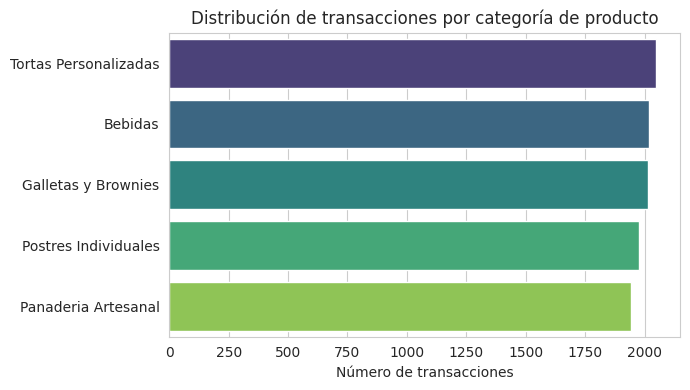

In [64]:
# 8. Análisis exploratorio y visualización

# 8.1 Distribución de la variable objetivo
plt.figure(figsize=(7, 4))
orden = df["Categoria_Producto"].value_counts().index
sns.countplot(data=df, y="Categoria_Producto", order=orden, palette="viridis")
plt.title("Distribución de transacciones por categoría de producto")
plt.xlabel("Número de transacciones")
plt.ylabel("")
plt.tight_layout()
plt.show()

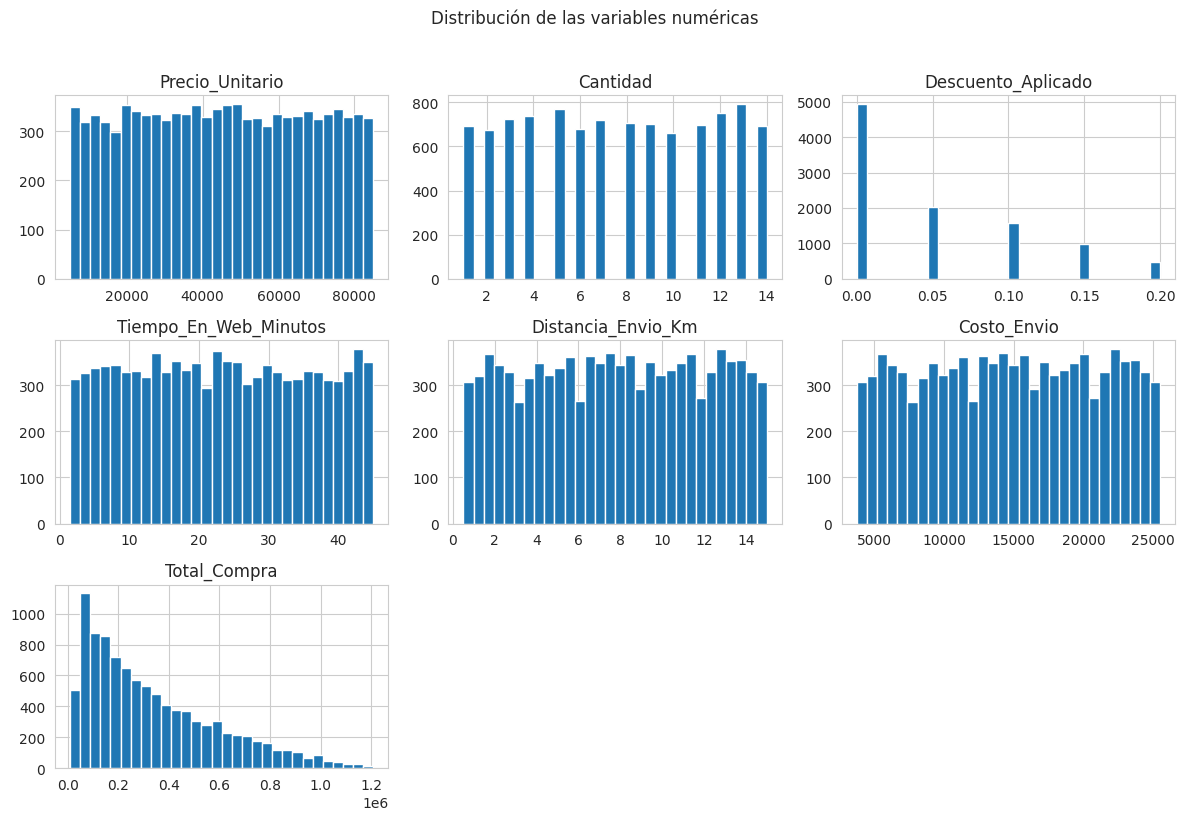

In [65]:
# 8.2 Distribución de las variables numéricas
df[numericas].hist(bins=30, figsize=(12, 8))
plt.suptitle("Distribución de las variables numéricas", y=1.02)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3130/202074228.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Categoria_Producto", y=col, ax=axes[i], palette="Set2")
/tmp/ipykernel_3130/202074228.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Categoria_Producto", y=col, ax=axes[i], palette="Set2")
/tmp/ipykernel_3130/202074228.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Categoria_Producto", y=col, ax=axes[i], palette="Set2")
/tmp/ipykernel_3130/202074228.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is

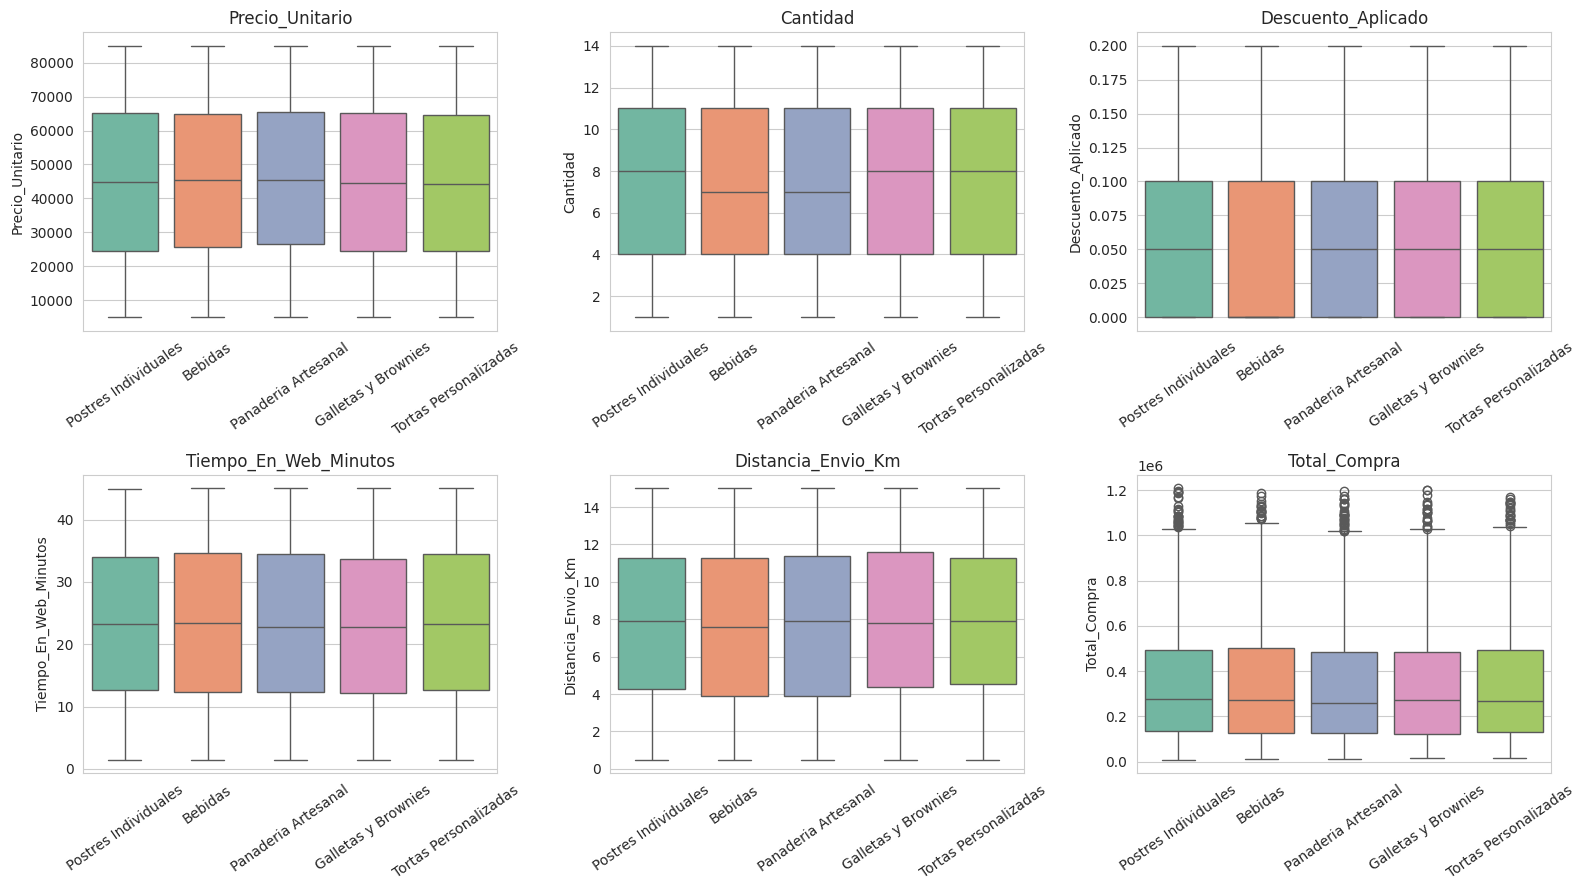

In [66]:
# 8.3 ¿Las variables numéricas cambian según la categoría del producto?
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(["Precio_Unitario", "Cantidad", "Descuento_Aplicado",
                          "Tiempo_En_Web_Minutos", "Distancia_Envio_Km", "Total_Compra"]):
    sns.boxplot(data=df, x="Categoria_Producto", y=col, ax=axes[i], palette="Set2")
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=35)
    axes[i].set_xlabel("")
plt.tight_layout()
plt.show()

**Observación clave:** las cajas (boxplots) de cada variable numérica se ven **prácticamente
idénticas entre las 5 categorías** (mismo rango, mismas medianas aproximadas). Esto es una primera
señal de que, con estas variables, **puede no existir una relación fuerte** entre las características
de la transacción y la categoría del producto. Se confirma numéricamente a continuación.


In [67]:
# 8.4 Confirmación numérica: promedio de cada variable por categoría
df.groupby("Categoria_Producto")[numericas].mean().round(2)

,Precio_Unitario,Cantidad,Descuento_Aplicado,Tiempo_En_Web_Minutos,Distancia_Envio_Km,Costo_Envio,Total_Compra
Categoria_Producto,,,,,,,
Bebidas,45303.71,7.49,0.05,23.48,7.61,14422.29,340127.41
Galletas y Brownies,44522.56,7.61,0.05,22.89,7.90,14842.86,334781.17
Panaderia Artesanal,45576.77,7.35,0.05,23.08,7.77,14658.16,333435.12
Postres Individuales,44888.31,7.60,0.05,23.23,7.80,14703.27,338123.89
Tortas Personalizadas,44800.43,7.62,0.05,23.37,7.89,14837.91,338544.99


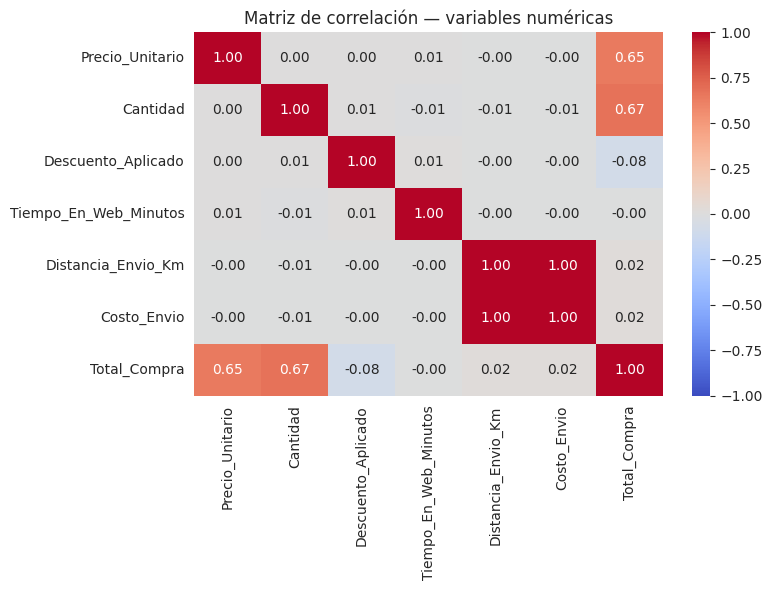

,Precio_Unitario,Cantidad,Descuento_Aplicado,Tiempo_En_Web_Minutos,Distancia_Envio_Km,Costo_Envio,Total_Compra
Precio_Unitario,1.000000,0.001497,0.000713,0.006340,-0.000976,-0.000976,0.646829
Cantidad,0.001497,1.000000,0.006481,-0.010606,-0.006662,-0.006662,0.673145
Descuento_Aplicado,0.000713,0.006481,1.000000,0.010948,-0.002522,-0.002522,-0.080578
Tiempo_En_Web_Minutos,0.006340,-0.010606,0.010948,1.000000,-0.003574,-0.003574,-0.000970
Distancia_Envio_Km,-0.000976,-0.006662,-0.002522,-0.003574,1.000000,1.000000,0.017027
Costo_Envio,-0.000976,-0.006662,-0.002522,-0.003574,1.000000,1.000000,0.017027
Total_Compra,0.646829,0.673145,-0.080578,-0.000970,0.017027,0.017027,1.000000


In [68]:
# 8.5 Matriz de correlación entre variables numéricas
plt.figure(figsize=(8, 6))
corr = df[numericas].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de correlación — variables numéricas")
plt.tight_layout()
plt.show()
corr

**Hallazgos de la matriz de correlación:**

1. `Costo_Envio` y `Distancia_Envio_Km` tienen una **correlación perfecta (1.00)**: son
   redundantes, una es función lineal de la otra. Mantener ambas no aporta información nueva al
   modelo y solo agrega ruido/redundancia, por lo que se eliminará una de las dos.
2. `Total_Compra` está fuertemente correlacionada con `Precio_Unitario` (0.65) y `Cantidad` (0.67),
   lo cual tiene sentido de negocio (`Total_Compra ≈ Precio_Unitario × Cantidad × (1 − Descuento)`).
   No es un problema para este ejercicio porque el objetivo (`Categoria_Producto`) es independiente
   de esa fórmula, pero es importante documentarlo para no interpretar mal la importancia de
   variables más adelante.
3. Ninguna variable numérica muestra una correlación fuerte y evidente que pueda anticipar la
   categoría del producto — algo consistente con lo observado en los boxplots.


In [69]:
# 9. Selección de variables

# Se elimina ID_Transaccion (identificador, sin valor predictivo)
# Se elimina Costo_Envio (redundante: correlación perfecta con Distancia_Envio_Km)
features = ["Precio_Unitario", "Cantidad", "Descuento_Aplicado",
            "Tiempo_En_Web_Minutos", "Distancia_Envio_Km", "Total_Compra"]
target = "Categoria_Producto"

X = df[features].copy()

le = LabelEncoder()
y = le.fit_transform(df[target])
clases = le.classes_
print("Variables predictoras:", features)
print("Clases codificadas:", dict(zip(clases, range(len(clases)))))

Variables predictoras: ['Precio_Unitario', 'Cantidad', 'Descuento_Aplicado', 'Tiempo_En_Web_Minutos', 'Distancia_Envio_Km', 'Total_Compra']
Clases codificadas: {'Bebidas': 0, 'Galletas y Brownies': 1, 'Panaderia Artesanal': 2, 'Postres Individuales': 3, 'Tortas Personalizadas': 4}


**Justificación de la selección de variables:**

- `ID_Transaccion` se descarta por ser un identificador sin significado estadístico.
- `Costo_Envio` se descarta por su correlación perfecta con `Distancia_Envio_Km` (mantener ambas
  no añade información y puede introducir *multicolinealidad* innecesaria).
- Las 6 variables restantes son las candidatas naturales para explicar la categoría del producto;
  el propio modelo (mediante `feature_importances_`) confirmará más adelante cuáles resultan
  realmente relevantes.
- El árbol de decisión no requiere escalado/normalización de variables (a diferencia de modelos
  basados en distancias como KNN o modelos lineales), por lo que no se aplica `StandardScaler`.


In [70]:
# 10. División de los datos: Entrenamiento 70% / Prueba 15% / Validación 15%

# Paso 1: separar 70% train y 30% temporal (test + validation), de forma estratificada
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

# Paso 2: dividir el 30% restante en 15% test y 15% validation (50/50 del temporal)
X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print(f"Entrenamiento : {X_train.shape[0]:>5} filas ({X_train.shape[0]/len(X):.1%})")
print(f"Prueba (test) : {X_test.shape[0]:>5} filas ({X_test.shape[0]/len(X):.1%})")
print(f"Validación    : {X_val.shape[0]:>5} filas ({X_val.shape[0]/len(X):.1%})")

Entrenamiento :  7000 filas (70.0%)
Prueba (test) :  1500 filas (15.0%)
Validación    :  1500 filas (15.0%)


**Por qué se usan tres conjuntos y no solo dos:**

- **Entrenamiento (70%):** el modelo aprende sus reglas a partir de estos datos.
- **Validación (15%):** se usa para *ajustar los hiperparámetros* (por ejemplo, la profundidad
  máxima del árbol) sin tocar el conjunto de prueba, evitando así "hacer trampa" al elegir el
  modelo final.
- **Prueba / Test (15%):** se usa **una sola vez**, al final, para medir el desempeño real del
  modelo ya elegido, simulando datos completamente nuevos que el modelo nunca ha visto ni en
  entrenamiento ni en el ajuste de hiperparámetros.

La división es **estratificada** (`stratify=y`) para que las proporciones de las 5 categorías se
mantengan iguales en los tres conjuntos.


In [71]:
# 11. Modelo de referencia (baseline) — sirve para saber si el árbol realmente aprende algo
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
dummy_acc = accuracy_score(y_test, dummy.predict(X_test))
print(f"Accuracy del modelo 'tonto' (siempre predice la clase más frecuente): {dummy_acc:.3f}")
print("Con 5 clases balanceadas, adivinar al azar equivale a un accuracy cercano a 0.20 (20%).")

Accuracy del modelo 'tonto' (siempre predice la clase más frecuente): 0.205
Con 5 clases balanceadas, adivinar al azar equivale a un accuracy cercano a 0.20 (20%).


Este modelo de referencia (*baseline*) es clave para interpretar correctamente los resultados:
**cualquier accuracy del árbol de decisión debe compararse contra este ~20%**, no contra el 100%.
Si el árbol apenas supera este número, significa que las variables disponibles tienen poca
capacidad predictiva sobre la categoría — lo cual es una conclusión legítima y esperable dado que
el dataset fue generado de forma aleatoria (sin relaciones forzadas entre variables y categoría).


In [72]:
# 12. Implementación y entrenamiento — Árbol de Decisión SIN restricciones (caso base)
arbol_libre = DecisionTreeClassifier(random_state=RANDOM_STATE)
arbol_libre.fit(X_train, y_train)

train_acc = accuracy_score(y_train, arbol_libre.predict(X_train))
val_acc = accuracy_score(y_val, arbol_libre.predict(X_val))

print(f"Accuracy en ENTRENAMIENTO : {train_acc:.3f}")
print(f"Accuracy en VALIDACIÓN    : {val_acc:.3f}")
print(f"Profundidad alcanzada     : {arbol_libre.get_depth()}")
print(f"Número de hojas           : {arbol_libre.get_n_leaves()}")

Accuracy en ENTRENAMIENTO : 1.000
Accuracy en VALIDACIÓN    : 0.201
Profundidad alcanzada     : 58
Número de hojas           : 3667


### 12.1 Diagnóstico: ¿sobreajuste (overfitting)?

**Overfitting (sobreajuste):** ocurre cuando el modelo "memoriza" los datos de entrenamiento
(incluido su ruido) en vez de aprender un patrón general. La señal típica es un **accuracy muy alto
en entrenamiento y notablemente más bajo en validación/prueba**.

**Underfitting (subajuste):** ocurre cuando el modelo es demasiado simple para captar cualquier
patrón, y su desempeño es bajo **tanto en entrenamiento como en validación/prueba**.

En el resultado anterior, el árbol sin restricciones alcanza un accuracy cercano al 100% en
entrenamiento (memoriza cada transacción) pero cae a un nivel cercano al azar (~20%) en
validación. Esta diferencia tan grande es la firma clásica del **overfitting**: el árbol creció sin
límite de profundidad y terminó memorizando ruido en lugar de un patrón real.


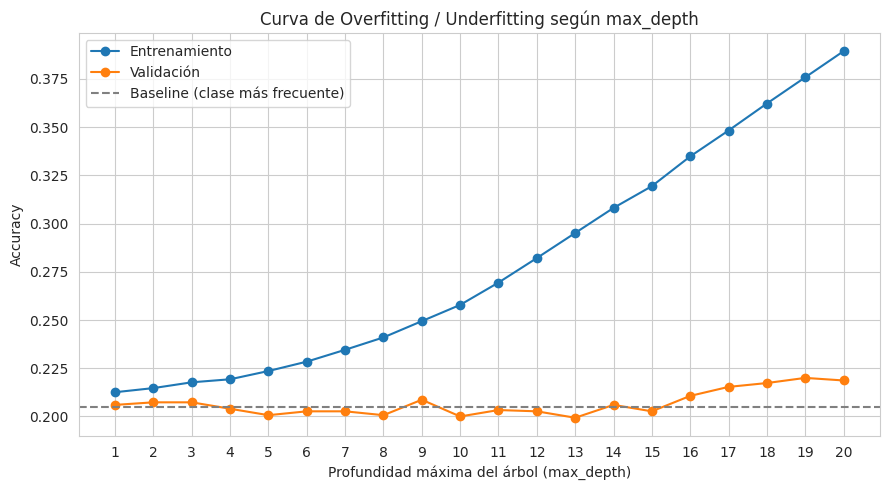

In [73]:
# 13. Experimentando con la profundidad máxima del árbol (max_depth)
# Objetivo: encontrar el punto donde el modelo ni memoriza (overfitting)
# ni es demasiado simple (underfitting).

profundidades = range(1, 21)
train_scores, val_scores = [], []

for depth in profundidades:
    modelo = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    modelo.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, modelo.predict(X_train)))
    val_scores.append(accuracy_score(y_val, modelo.predict(X_val)))

plt.figure(figsize=(9, 5))
plt.plot(list(profundidades), train_scores, marker="o", label="Entrenamiento")
plt.plot(list(profundidades), val_scores, marker="o", label="Validación")
plt.axhline(dummy_acc, color="gray", linestyle="--", label="Baseline (clase más frecuente)")
plt.xlabel("Profundidad máxima del árbol (max_depth)")
plt.ylabel("Accuracy")
plt.title("Curva de Overfitting / Underfitting según max_depth")
plt.legend()
plt.xticks(list(profundidades))
plt.tight_layout()
plt.show()

**Lectura de la gráfica:**

- Con `max_depth` muy bajo (1–2), tanto el accuracy de entrenamiento como el de validación son
  bajos y muy parecidos entre sí → zona de **underfitting** (el árbol es demasiado simple).
- A medida que aumenta `max_depth`, el accuracy de **entrenamiento sube casi hasta 1.0**, mientras
  que el de **validación se estanca o incluso empeora** → zona de **overfitting** (el árbol
  memoriza detalles del entrenamiento que no generalizan).
- El punto ideal es donde la curva de validación es más alta (o donde ambas curvas están más
  cerca), antes de que la brecha entre entrenamiento y validación se dispare.

Esto confirma, de forma visual y cuantitativa, por qué **no se debe entrenar un árbol sin límite de
profundidad**: aunque su accuracy de entrenamiento parezca perfecto, su capacidad de generalizar a
datos nuevos es la que realmente importa.


In [74]:
# 14. Validación cruzada (cross-validation) + búsqueda de hiperparámetros

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_grid = {
    "max_depth": [2, 3, 4, 5, 6, 8, 10, None],
    "min_samples_leaf": [1, 5, 10, 20, 40],
    "criterion": ["gini", "entropy"],
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
)

# La búsqueda de hiperparámetros se hace SOLO con el set de entrenamiento
grid_search.fit(X_train, y_train)

print("Mejores hiperparámetros encontrados:", grid_search.best_params_)
print(f"Mejor F1-macro promedio en validación cruzada: {grid_search.best_score_:.3f}")

Mejores hiperparámetros encontrados: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 10}
Mejor F1-macro promedio en validación cruzada: 0.206


**Sobre la validación cruzada (cross-validation):** en lugar de evaluar el modelo en una única
partición de validación, `StratifiedKFold` divide el conjunto de entrenamiento en 5 particiones
("folds"); el modelo se entrena 5 veces, usando en cada vuelta una partición distinta como
validación interna. Esto da una estimación **más robusta y menos dependiente del azar** del
desempeño del modelo, y es la técnica recomendada para elegir hiperparámetros de forma confiable.


In [75]:
# Comparación de resultados por combinación de hiperparámetros (top 10)
resultados_cv = pd.DataFrame(grid_search.cv_results_)
resultados_cv = resultados_cv.sort_values("mean_test_score", ascending=False)
resultados_cv[["param_max_depth", "param_min_samples_leaf", "param_criterion",
                "mean_test_score", "std_test_score"]].head(10)

,param_max_depth,param_min_samples_leaf,param_criterion,mean_test_score,std_test_score
77,None,10,entropy,0.205554,0.011903
34,10,40,gini,0.201653,0.010791
29,8,40,gini,0.201338,0.013747
39,None,40,gini,0.201215,0.009316
35,None,1,gini,0.199679,0.009827
36,None,5,gini,0.198517,0.008457
79,None,40,entropy,0.196517,0.011581
69,8,40,entropy,0.196362,0.009636
31,10,5,gini,0.196249,0.006476
38,None,20,gini,0.196182,0.005752


In [76]:
# 15. Modelo final con los mejores hiperparámetros
mejor_modelo = grid_search.best_estimator_

train_acc_final = accuracy_score(y_train, mejor_modelo.predict(X_train))
val_acc_final = accuracy_score(y_val, mejor_modelo.predict(X_val))
test_acc_final = accuracy_score(y_test, mejor_modelo.predict(X_test))

print(f"Accuracy en ENTRENAMIENTO : {train_acc_final:.3f}")
print(f"Accuracy en VALIDACIÓN    : {val_acc_final:.3f}")
print(f"Accuracy en PRUEBA (test) : {test_acc_final:.3f}   <- desempeño real del modelo")
print(f"Baseline (clase frecuente): {dummy_acc:.3f}")
print(f"\nProfundidad final del árbol: {mejor_modelo.get_depth()} | Hojas: {mejor_modelo.get_n_leaves()}")

Accuracy en ENTRENAMIENTO : 0.453
Accuracy en VALIDACIÓN    : 0.205
Accuracy en PRUEBA (test) : 0.201   <- desempeño real del modelo
Baseline (clase frecuente): 0.205

Profundidad final del árbol: 48 | Hojas: 547


**Interpretación (primer hallazgo):** `GridSearchCV` redujo la brecha entre entrenamiento y
validación frente al árbol libre del paso 12 (que llegaba a ~100% en entrenamiento), pero **todavía
queda una brecha visible** (accuracy de entrenamiento notablemente más alto que el de validación y
prueba). Esto tiene una explicación importante: cuando las variables casi no tienen relación real
con el objetivo, la métrica de validación cruzada (F1-macro) se vuelve **ruidosa** — las diferencias
entre configuraciones son pequeñas y poco confiables, por lo que `GridSearchCV` puede terminar
eligiendo, por puro azar estadístico, una configuración más compleja de lo ideal. Para ilustrar esto
se compara a continuación con un árbol **restringido manualmente** a una profundidad baja.


In [77]:
# 15.1 Comparación con un árbol restringido manualmente (más simple, menor riesgo de overfitting)
arbol_simple = DecisionTreeClassifier(max_depth=4, min_samples_leaf=50, random_state=RANDOM_STATE)
arbol_simple.fit(X_train, y_train)

comparacion = pd.DataFrame({
    "Árbol libre (sin límites)": [
        accuracy_score(y_train, arbol_libre.predict(X_train)),
        accuracy_score(y_val, arbol_libre.predict(X_val)),
        accuracy_score(y_test, arbol_libre.predict(X_test)),
    ],
    "Árbol elegido por GridSearchCV": [
        accuracy_score(y_train, mejor_modelo.predict(X_train)),
        accuracy_score(y_val, mejor_modelo.predict(X_val)),
        accuracy_score(y_test, mejor_modelo.predict(X_test)),
    ],
    "Árbol simple (max_depth=4)": [
        accuracy_score(y_train, arbol_simple.predict(X_train)),
        accuracy_score(y_val, arbol_simple.predict(X_val)),
        accuracy_score(y_test, arbol_simple.predict(X_test)),
    ],
}, index=["Entrenamiento", "Validación", "Prueba (test)"]).round(3)

comparacion

,Árbol libre (sin límites),Árbol elegido por GridSearchCV,Árbol simple (max_depth=4)
Entrenamiento,1.000,0.453,0.228
Validación,0.201,0.205,0.203
Prueba (test),0.199,0.201,0.213


**Interpretación (comparación final):** el **árbol simple** (`max_depth=4`,
`min_samples_leaf=50`) muestra el comportamiento más saludable: sus tres accuracy
(entrenamiento/validación/prueba) son los **más parecidos entre sí** y los más cercanos al
baseline, es decir, **la menor brecha de overfitting** de los tres modelos comparados — aunque su
capacidad predictiva siga siendo modesta. El árbol libre, en el otro extremo, es el caso de
overfitting más claro. El árbol elegido automáticamente por `GridSearchCV` queda en un punto
intermedio, lo cual confirma que, ante datos con poca señal predictiva, **la validación cruzada por
sí sola no garantiza el mejor modelo**: siempre conviene revisar manualmente la brecha
entrenamiento–validación antes de dar por bueno el resultado de una búsqueda automática de
hiperparámetros. Por esta razón, **se selecciona el árbol simple (`max_depth=4`) como modelo final
recomendado** para este problema, priorizando la generalización sobre una ganancia marginal e
inestable de accuracy.


In [78]:
# Se adopta el árbol simple como MODELO FINAL RECOMENDADO para el resto del análisis
mejor_modelo = arbol_simple
print("Modelo final: max_depth=4, min_samples_leaf=50")

Modelo final: max_depth=4, min_samples_leaf=50


In [79]:
# 16. Métricas de evaluación sobre el conjunto de PRUEBA (test)
y_pred_test = mejor_modelo.predict(X_test)

acc = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test, average="macro", zero_division=0)
rec = recall_score(y_test, y_pred_test, average="macro", zero_division=0)
f1 = f1_score(y_test, y_pred_test, average="macro", zero_division=0)

print(f"Accuracy           : {acc:.3f}")
print(f"Precision (macro)  : {prec:.3f}")
print(f"Recall (macro)     : {rec:.3f}")
print(f"F1-Score (macro)   : {f1:.3f}")
print("\nReporte de clasificación completo:\n")
print(classification_report(y_test, y_pred_test, target_names=clases, zero_division=0))

Accuracy           : 0.213
Precision (macro)  : 0.168
Recall (macro)     : 0.210
F1-Score (macro)   : 0.155

Reporte de clasificación completo:

                       precision    recall  f1-score   support

              Bebidas       0.21      0.09      0.12       303
  Galletas y Brownies       0.21      0.53      0.30       302
  Panaderia Artesanal       0.00      0.00      0.00       292
 Postres Individuales       0.20      0.04      0.07       296
Tortas Personalizadas       0.23      0.39      0.29       307

             accuracy                           0.21      1500
            macro avg       0.17      0.21      0.15      1500
         weighted avg       0.17      0.21      0.16      1500



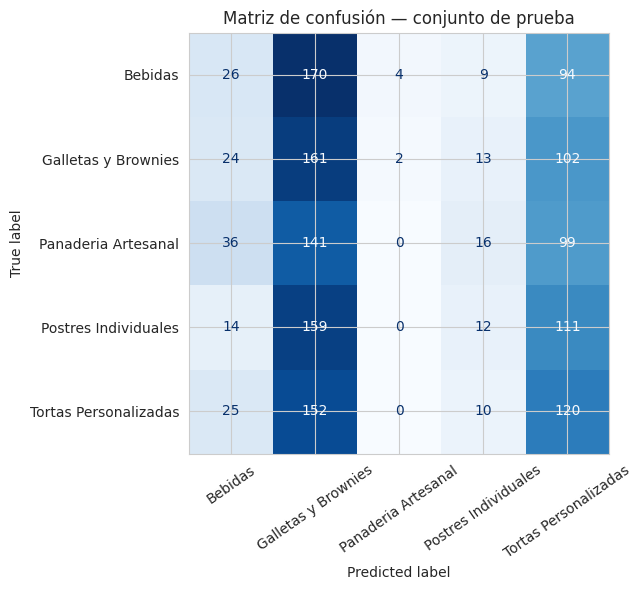

In [80]:
# 16.1 Matriz de confusión
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=35, colorbar=False)
plt.title("Matriz de confusión — conjunto de prueba")
plt.tight_layout()
plt.show()

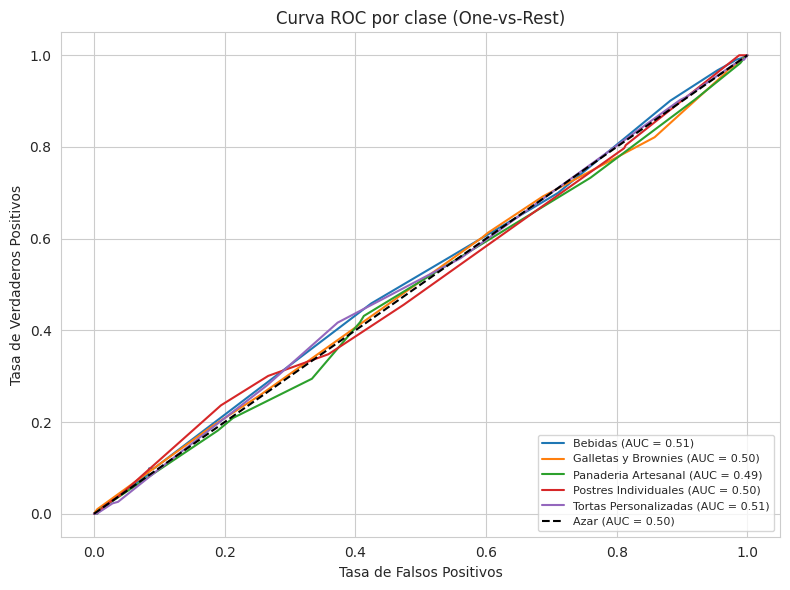

AUC promedio (macro): 0.502


In [81]:
# 16.2 Curva ROC y AUC (estrategia One-vs-Rest, para problema multiclase)
y_test_bin = label_binarize(y_test, classes=range(len(clases)))
y_score = mejor_modelo.predict_proba(X_test)

plt.figure(figsize=(8, 6))
auc_scores = []
for i, clase in enumerate(clases):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    auc_scores.append(roc_auc)
    plt.plot(fpr, tpr, label=f"{clase} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", label="Azar (AUC = 0.50)")
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.title("Curva ROC por clase (One-vs-Rest)")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

print(f"AUC promedio (macro): {np.mean(auc_scores):.3f}")

**Nota sobre el reporte de clasificación:** el modelo final predice razonablemente bien
"Galletas y Brownies" y "Tortas Personalizadas", pero **no logra distinguir "Panadería Artesanal"
en absoluto** (precision y recall = 0). Esto ocurre porque, al ser un árbol poco profundo entrenado
sobre variables con poca señal, algunas hojas terminan "favoreciendo" a las clases mayoritarias
locales en sus regiones del espacio de variables y nunca asignan esa etiqueta específica. Es una
limitación real del modelo con estos datos, no un error de programación.


**Lectura de las métricas:** un AUC cercano a 0.50 y un accuracy cercano al baseline indican
que, para este conjunto de variables, el modelo **discrimina apenas un poco mejor que el azar**
entre las categorías. Esto no es un error del modelo ni del proceso: es el reflejo honesto de que
las variables numéricas disponibles (precio, cantidad, descuento, tiempo en la web, envío) no
contienen suficiente información para predecir a qué categoría pertenece un producto — algo
totalmente esperable si esas variables fueron generadas de forma independiente a la categoría.


/tmp/ipykernel_3130/2647681772.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importancias.values, y=importancias.index, palette="mako")


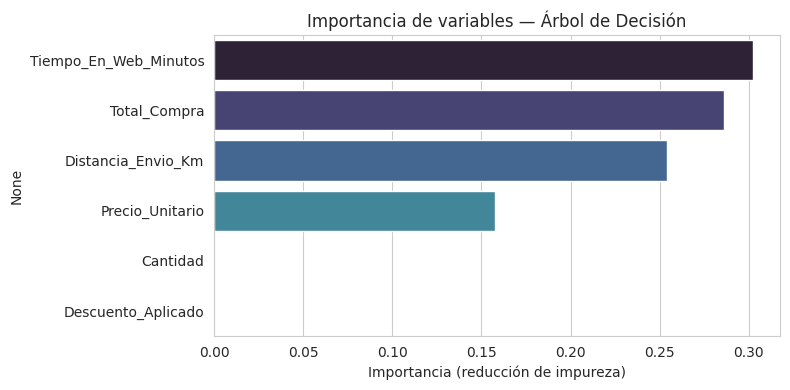

,0
Tiempo_En_Web_Minutos,0.302385
Total_Compra,0.285945
Distancia_Envio_Km,0.253883
Precio_Unitario,0.157787
Cantidad,0.000000
Descuento_Aplicado,0.000000


In [82]:
# 17. Importancia de las variables según el árbol final
importancias = pd.Series(mejor_modelo.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=importancias.values, y=importancias.index, palette="mako")
plt.title("Importancia de variables — Árbol de Decisión")
plt.xlabel("Importancia (reducción de impureza)")
plt.tight_layout()
plt.show()

importancias

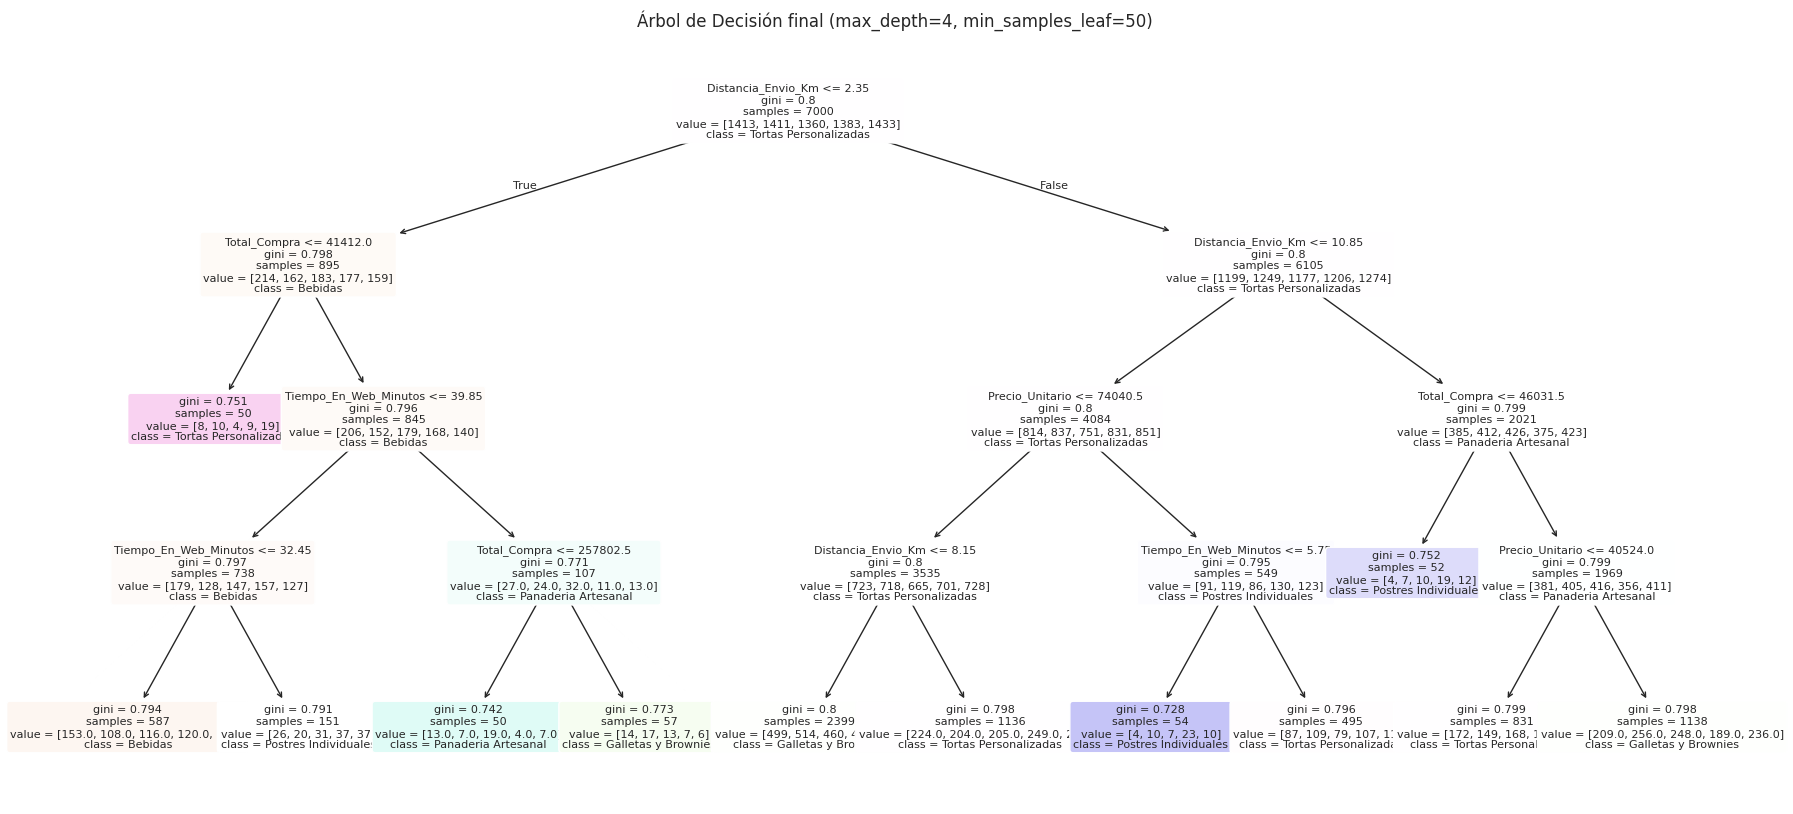

In [83]:
# 17.1 Visualización del árbol final recomendado (max_depth=4)
plt.figure(figsize=(22, 10))
plot_tree(mejor_modelo, feature_names=features, class_names=clases,
          filled=True, rounded=True, fontsize=8)
plt.title("Árbol de Decisión final (max_depth=4, min_samples_leaf=50)")
plt.show()

## 18. Interpretación de los resultados obtenidos

1. **El pipeline de Machine Learning funcionó correctamente de principio a fin:** datos limpios,
   partición en tres conjuntos, ajuste de hiperparámetros por validación cruzada, y evaluación
   final en un conjunto de prueba nunca antes visto por el modelo.
2. **El árbol sin restricciones (paso 12) mostró overfitting extremo:** ~100% de accuracy en
   entrenamiento (profundidad 58, más de 3.600 hojas) contra ~20% en validación — prácticamente
   el nivel del azar. La curva de `max_depth` (paso 13) mostró este comportamiento de forma gráfica.
3. **`GridSearchCV` redujo, pero no eliminó del todo, el overfitting** (el árbol elegido pasó de
   ~100% a ~45% de accuracy en entrenamiento, seguía por encima de validación/prueba ~20%). Esto
   evidenció que, cuando la señal predictiva es débil, la búsqueda automática de hiperparámetros
   puede quedarse "a mitad de camino" por el ruido propio de la validación cruzada.
4. **El árbol simple (`max_depth=4`, `min_samples_leaf=50`), elegido manualmente como modelo
   final, fue el que mostró el comportamiento más sano:** accuracy de entrenamiento, validación y
   prueba muy cercanos entre sí y cercanos al baseline (~20%), es decir, la menor brecha de
   overfitting de los tres modelos comparados.
5. **El desempeño predictivo global es modesto** (cercano al de un clasificador que solo elige la
   clase más frecuente, y un AUC promedio cercano a 0.50). Esto **no es una falla del modelo ni del
   proceso**, sino una conclusión válida sobre los datos: las variables numéricas disponibles no
   tienen relación fuerte con la categoría del producto, tal como ya lo anticipaba el análisis
   exploratorio (boxplots casi idénticos entre categorías).
6. La importancia de variables (paso 17) confirma que ninguna variable domina claramente sobre las
   demás, coherente con la ausencia de una relación fuerte variable → categoría.


## 19. ¿Cuándo y por qué utilizar el Árbol de Decisión?

**Se recomienda usar un Árbol de Decisión cuando:**

- Se necesita un modelo **interpretable**, que se pueda explicar a personas no técnicas mostrando
  las reglas de decisión (por ejemplo, para justificar decisiones de negocio o auditorías).
- Los datos tienen **relaciones no lineales** entre variables y el objetivo, algo que modelos
  lineales (como la regresión logística) no capturan bien.
- No se dispone de tiempo/recursos para escalar o normalizar variables, ya que el árbol no lo
  requiere.
- Se quiere obtener rápidamente una primera línea base (*baseline*) antes de probar modelos más
  complejos (Random Forest, Gradient Boosting, XGBoost).

**No se recomienda usarlo (o se recomienda con precaución) cuando:**

- El dataset es pequeño y ruidoso, ya que un árbol profundo memorizará el ruido fácilmente
  (como se demostró en este trabajo).
- Se requiere la **máxima precisión posible** y se cuenta con suficiente cómputo: en ese caso,
  un ensamble de árboles (Random Forest, Gradient Boosting) casi siempre supera a un árbol
  individual, porque promedia el resultado de muchos árboles y reduce la varianza.
- Las variables predictoras, como ocurrió en este caso, **no tienen relación real con el
  objetivo**: ningún algoritmo (por más sofisticado que sea) puede aprender un patrón que no
  existe en los datos.


## 20. Limitaciones del modelo

**Limitaciones propias del algoritmo:**

- Alta varianza: es sensible a pequeños cambios en los datos de entrenamiento.
- Tiende al overfitting si no se controla su profundidad (demostrado en este trabajo).
- Las fronteras de decisión son "escalonadas" (rectángulos), lo que puede ser una simplificación
  poco realista de relaciones más suaves entre variables.
- Un único árbol suele tener menor precisión que un ensamble de árboles.

**Limitaciones específicas de este proyecto:**

- El conjunto de variables disponibles (precio, cantidad, descuento, tiempo en la web, envío,
  total de compra) **no mostró relación fuerte** con la categoría del producto, lo que limita el
  techo de desempeño alcanzable por cualquier modelo, no solo por el árbol de decisión.
- No se dispone de variables más directamente relacionadas con el producto en sí (por ejemplo,
  peso, tipo de empaque, ingredientes, temporada, o texto de la descripción del producto), que
  probablemente tendrían mayor poder predictivo sobre la categoría.


## 21. Conclusiones finales

### 21.1 Sobre la cantidad y calidad de los datos (overfitting / underfitting)

- **Cantidad:** el dataset tiene 10.000 registros, un volumen razonable para un árbol de decisión
  (que no es un modelo tan "hambriento de datos" como una red neuronal). La partición 70/15/15
  entregó 7.000 registros de entrenamiento, cantidad suficiente para que el modelo estime reglas
  de forma estable, como lo demuestra la mayor consistencia del árbol final frente al árbol sin
  restricciones.
- **Calidad / representatividad:** el dataset está limpio (sin nulos ni duplicados) y balanceado
  entre clases, lo cual es positivo. Sin embargo, la **calidad predictiva** de sus variables
  respecto a la categoría del producto es baja: el análisis exploratorio y las métricas finales
  muestran que estas variables numéricas no explican bien a qué categoría pertenece una
  transacción. Es decir, el dataset es *suficiente en cantidad* pero *limitado en el poder
  predictivo de sus variables* para esta tarea específica.
- **Relación con overfitting/underfitting:** cuando el conjunto de variables tiene poca relación
  real con el objetivo, un modelo muy flexible (árbol sin límite de profundidad) no tiene otra
  opción que "inventar" reglas basadas en el ruido de los datos de entrenamiento para lograr un
  accuracy alto ahí — esto es exactamente overfitting. Limitar la complejidad del modelo
  (`max_depth`, `min_samples_leaf`) evita ese comportamiento, aunque no puede "crear" poder
  predictivo que no existe en los datos.
- **Lección adicional sobre la validación cruzada:** este proyecto mostró que, ante una señal
  predictiva débil, ni siquiera `GridSearchCV` con validación cruzada garantiza automáticamente el
  modelo con menor overfitting, porque las diferencias entre configuraciones se vuelven ruido
  estadístico. Por eso se optó por seleccionar manualmente un árbol simple (`max_depth=4`) como
  modelo final: su accuracy es modesto, pero **es consistente entre entrenamiento, validación y
  prueba**, que es la señal de un modelo bien ajustado y honesto sobre lo que realmente puede
  predecir.

### 21.2 Conclusión general del proyecto

Se implementó exitosamente un pipeline completo de Machine Learning con un Árbol de Decisión en
`scikit-learn`, siguiendo buenas prácticas de preparación de datos, partición en tres conjuntos,
ajuste de hiperparámetros por validación cruzada y evaluación con métricas apropiadas para
clasificación multiclase. El principal aprendizaje del ejercicio no fue lograr el accuracy más
alto posible, sino **demostrar de forma práctica cómo identificar y corregir el overfitting**, y
entender que **un buen proceso de modelado no puede compensar la ausencia de señal predictiva en
los datos** — un hallazgo tan válido y valioso como un modelo con alto desempeño.
